# Baseline - TF-IDF + Classificador

Implementação de um modelo baseline para classificação de abstratos médicos.
Abordagem: TF-IDF + Logistic Regression / Naive Bayes

**Objetivo:** Estabelecer uma baseline reproduzível para comparação com modelos mais complexos.

## 1. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Configurações
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Paths
DATA_PATH = '../data/medical_tc_train.csv'

print(f"Random seed: {RANDOM_SEED}")

Random seed: 42


## 2. Carregamento dos Dados

In [2]:
# Carregar dataset
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")
print(f"\nDistribuição de labels:")
print(df['condition_label'].value_counts().sort_index())

Dataset shape: (11550, 2)
Colunas: ['condition_label', 'medical_abstract']

Distribuição de labels:
condition_label
1    2530
2    1195
3    1540
4    2441
5    3844
Name: count, dtype: int64


## 3. Train/Test Split

In [3]:
# Separar features e target
X = df['medical_abstract']
y = df['condition_label']

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_SEED,
    stratify=y  # Preservar proporção de labels
)

print(f"Training set: {len(X_train)} amostras")
print(f"Test set: {len(X_test)} amostras")
print(f"\nDistribuição no training set:")
print(y_train.value_counts().sort_index())
print(f"\nDistribuição no test set:")
print(y_test.value_counts().sort_index())

Training set: 9240 amostras
Test set: 2310 amostras

Distribuição no training set:
condition_label
1    2024
2     956
3    1232
4    1953
5    3075
Name: count, dtype: int64

Distribuição no test set:
condition_label
1    506
2    239
3    308
4    488
5    769
Name: count, dtype: int64


## 4. TF-IDF Vectorizer

In [4]:
# Configurar TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,      # Limitar a 5000 features
    min_df=2,               # Ignorar termos em < 2 documentos
    max_df=0.8,             # Ignorar termos em > 80% dos documentos
    ngram_range=(1, 2),     # Unigramas e bigramas
    lowercase=True,
    stop_words='english'
)

# Fit e transform
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF shape (test): {X_test_tfidf.shape}")
print(f"\nNúmero de features: {len(vectorizer.get_feature_names_out())}")
print(f"Sparsidade do train: {1 - (X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))*100:.2f}%")

TF-IDF shape (train): (9240, 5000)
TF-IDF shape (test): (2310, 5000)

Número de features: 5000
Sparsidade do train: -0.31%


## 5. Logistic Regression

In [5]:
print("Treinando Logistic Regression...")
lr_model = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=1000,
    solver='lbfgs'
)

lr_model.fit(X_train_tfidf, y_train)
print("✓ Modelo treinado!")

y_train_pred_lr = lr_model.predict(X_train_tfidf)
y_test_pred_lr = lr_model.predict(X_test_tfidf)

print(f"\nAcurácia no training set: {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"Acurácia no test set:     {accuracy_score(y_test, y_test_pred_lr):.4f}")

Treinando Logistic Regression...
✓ Modelo treinado!

Acurácia no training set: 0.7390
Acurácia no test set:     0.5732


## 6. Naive Bayes (Comparação)

In [6]:
# Treinar Multinomial Naive Bayes
print("Treinando Multinomial Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
print("✓ Modelo treinado!")

# Predições
y_train_pred_nb = nb_model.predict(X_train_tfidf)
y_test_pred_nb = nb_model.predict(X_test_tfidf)

# Métricas de treino
print(f"\nAcurácia no training set: {accuracy_score(y_train, y_train_pred_nb):.4f}")

# Métricas de teste
print(f"Acurácia no test set: {accuracy_score(y_test, y_test_pred_nb):.4f}")

Treinando Multinomial Naive Bayes...
✓ Modelo treinado!

Acurácia no training set: 0.6555
Acurácia no test set: 0.5939


## 7. Métricas Detalhadas - Logistic Regression

In [7]:
print("="*80)
print("LOGISTIC REGRESSION")
print("="*80)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_lr, digits=4))

# Resumo de métricas
metrics_lr = {
    'Accuracy': accuracy_score(y_test, y_test_pred_lr),
    'Precision (macro)': precision_score(y_test, y_test_pred_lr, average='macro'),
    'Recall (macro)': recall_score(y_test, y_test_pred_lr, average='macro'),
    'F1 Score (macro)': f1_score(y_test, y_test_pred_lr, average='macro')
}

print("\nResumo de Métricas:")
for metric, value in metrics_lr.items():
    print(f"{metric:.<30} {value:.4f}")

LOGISTIC REGRESSION

Classification Report (Test Set):
              precision    recall  f1-score   support

           1     0.7067    0.7332    0.7197       506
           2     0.5085    0.3766    0.4327       239
           3     0.5193    0.3929    0.4473       308
           4     0.6652    0.6352    0.6499       488
           5     0.4752    0.5618    0.5149       769

    accuracy                         0.5732      2310
   macro avg     0.5750    0.5399    0.5529      2310
weighted avg     0.5754    0.5732    0.5708      2310


Resumo de Métricas:
Accuracy...................... 0.5732
Precision (macro)............. 0.5750
Recall (macro)................ 0.5399
F1 Score (macro).............. 0.5529


## 8. Confusion Matrix - Logistic Regression

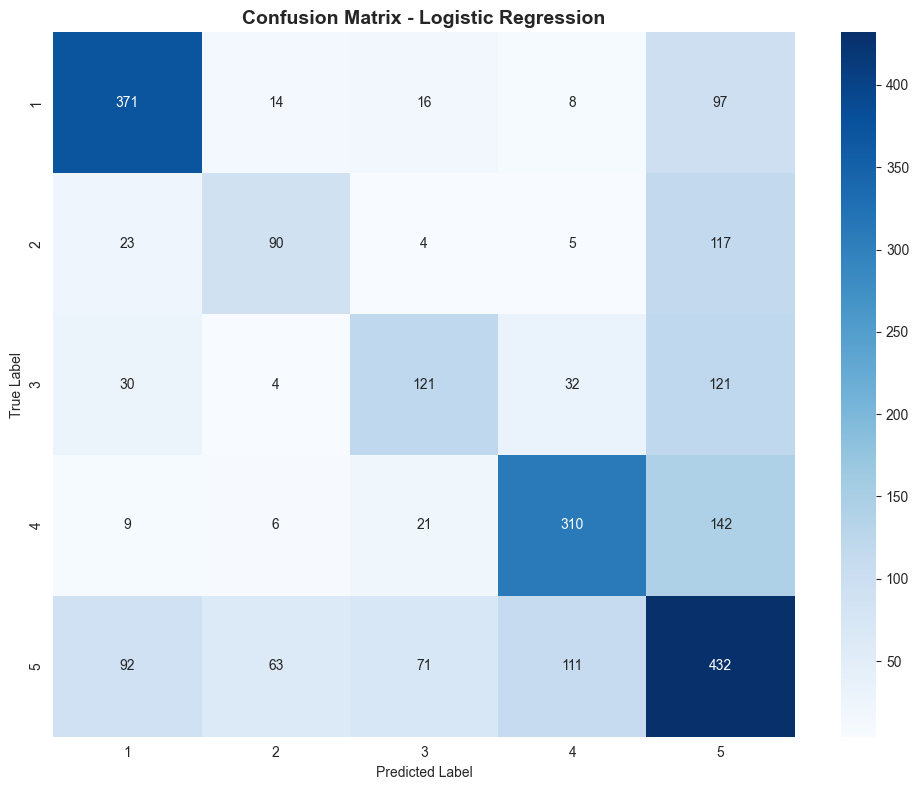

✓ Gráfico salvo em: reports/figures/04_confusion_matrix_lr.png


In [8]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('../reports/figures/04_confusion_matrix_lr.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo em: reports/figures/04_confusion_matrix_lr.png")

## 9. Métricas Detalhadas - Naive Bayes

In [9]:
print("="*80)
print("MULTINOMIAL NAIVE BAYES")
print("="*80)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_nb, digits=4))

# Resumo de métricas
metrics_nb = {
    'Accuracy': accuracy_score(y_test, y_test_pred_nb),
    'Precision (macro)': precision_score(y_test, y_test_pred_nb, average='macro'),
    'Recall (macro)': recall_score(y_test, y_test_pred_nb, average='macro'),
    'F1 Score (macro)': f1_score(y_test, y_test_pred_nb, average='macro')
}

print("\nResumo de Métricas:")
for metric, value in metrics_nb.items():
    print(f"{metric:.<30} {value:.4f}")

MULTINOMIAL NAIVE BAYES

Classification Report (Test Set):
              precision    recall  f1-score   support

           1     0.6968    0.7767    0.7346       506
           2     0.5615    0.3054    0.3957       239
           3     0.5612    0.3571    0.4365       308
           4     0.6745    0.7090    0.6913       488
           5     0.4961    0.5852    0.5370       769

    accuracy                         0.5939      2310
   macro avg     0.5980    0.5467    0.5590      2310
weighted avg     0.5932    0.5939    0.5849      2310


Resumo de Métricas:
Accuracy...................... 0.5939
Precision (macro)............. 0.5980
Recall (macro)................ 0.5467
F1 Score (macro).............. 0.5590


## 10. Confusion Matrix - Naive Bayes

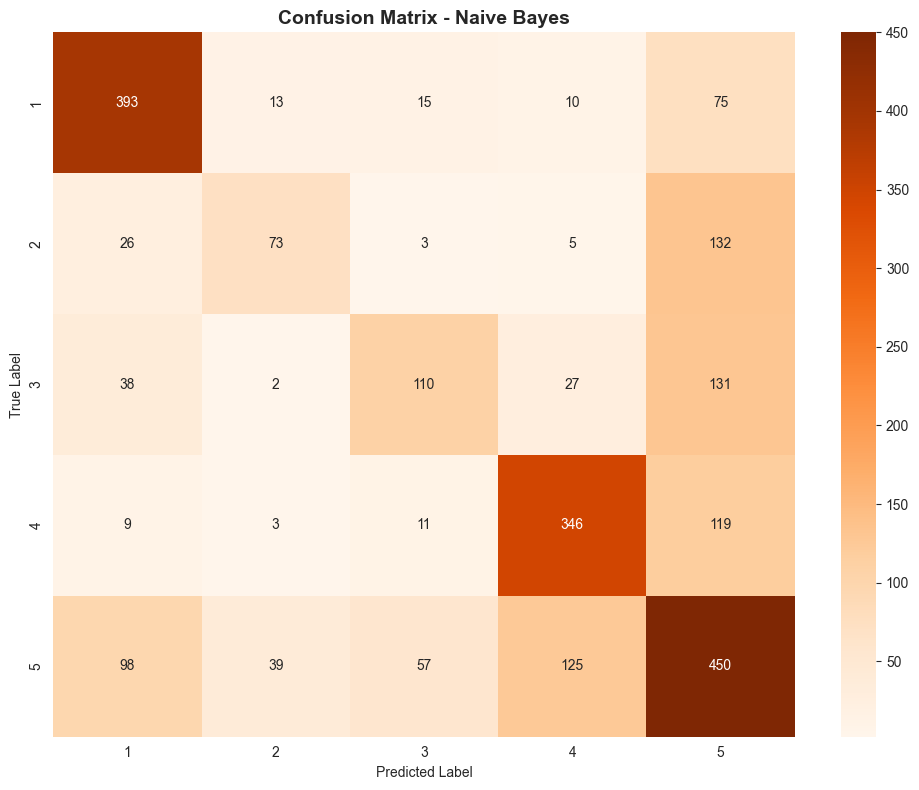

✓ Gráfico salvo em: reports/figures/05_confusion_matrix_nb.png


In [10]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_test_pred_nb)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', cbar=True,
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.title('Confusion Matrix - Naive Bayes', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('../reports/figures/05_confusion_matrix_nb.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo em: reports/figures/05_confusion_matrix_nb.png")

## 11. Comparação de Modelos


COMPARAÇÃO DE MODELOS
                   Logistic Regression  Naive Bayes
Accuracy                        0.5732       0.5939
Precision (macro)               0.5750       0.5980
Recall (macro)                  0.5399       0.5467
F1 Score (macro)                0.5529       0.5590


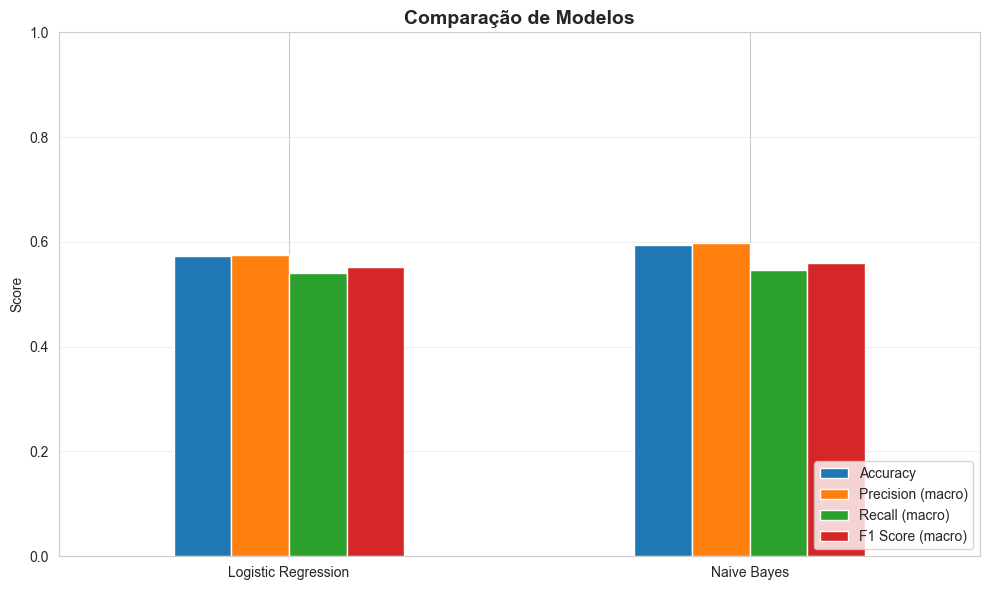

✓ Gráfico salvo em: reports/figures/06_model_comparison.png


In [11]:
# Comparar modelos
comparison_df = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'Naive Bayes': metrics_nb
})

print("\n" + "="*80)
print("COMPARAÇÃO DE MODELOS")
print("="*80)
print(comparison_df.round(4))

# Visualizar comparação
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.T.plot(kind='bar', ax=ax)
ax.set_title('Comparação de Modelos', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/06_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo em: reports/figures/06_model_comparison.png")

## 12. Feature Importance (Top Features)

Top 20 features mais discriminativas (Logistic Regression):
  cancer                              2.3572
  tumor                               1.7171
  hypertension                        1.6528
  carcinoma                           1.5951
  coronary                            1.4883
  brain                               1.4454
  myocardial                          1.3738
  cirrhosis                           1.3288
  tumors                              1.3155
  pain                                1.3017
  cholesterol                         1.2629
  leukemia                            1.2236
  artery                              1.2153
  cerebral                            1.2137
  diarrhea                            1.1902
  esophageal                          1.1757
  chronic                             1.1702
  heart                               1.1435
  gallbladder                         1.1292
  ventricular                         1.1211


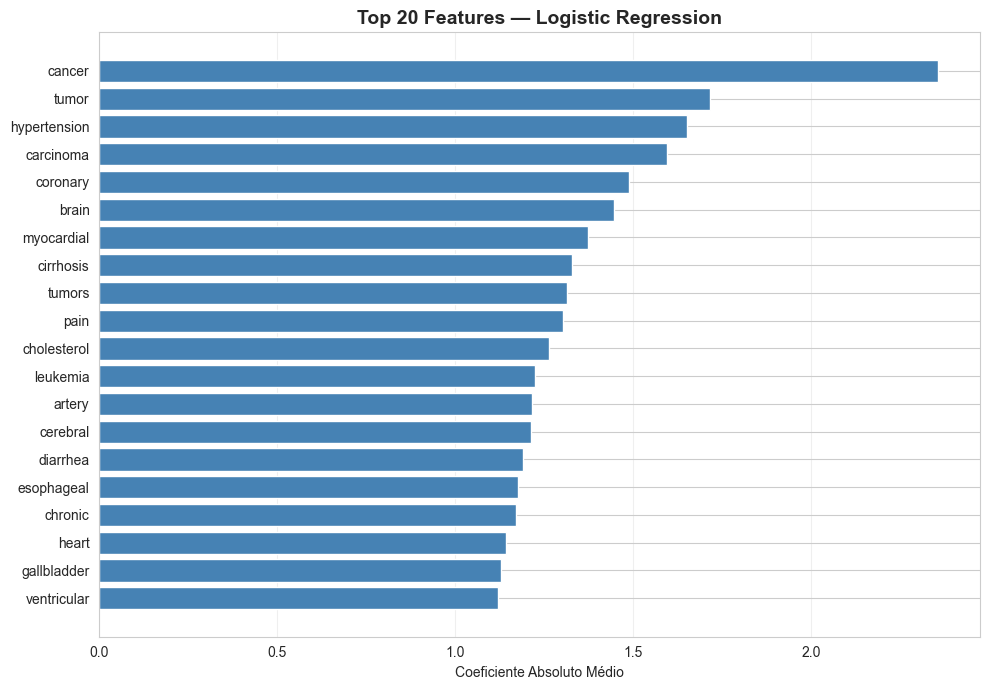

✓ Salvo: reports/figures/07_top_features.png


In [12]:
feature_names = vectorizer.get_feature_names_out()

# Top 20 features por coeficiente absoluto médio entre todas as classes
mean_abs_coef = np.abs(lr_model.coef_).mean(axis=0)
top_idx = mean_abs_coef.argsort()[-20:][::-1]
top_features = feature_names[top_idx]
top_scores = mean_abs_coef[top_idx]

print("Top 20 features mais discriminativas (Logistic Regression):")
for feat, score in zip(top_features, top_scores):
    print(f"  {feat:<35} {score:.4f}")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(top_features)), top_scores[::-1], color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features[::-1], fontsize=10)
ax.set_xlabel('Coeficiente Absoluto Médio')
ax.set_title('Top 20 Features — Logistic Regression', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/07_top_features.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Salvo: reports/figures/07_top_features.png")

## 13. Resumo Executivo

In [13]:
print("\n" + "="*80)
print("RESUMO EXECUTIVO")
print("="*80)

print("\n📊 BASELINE MODELS:")
print(f"  • Logistic Regression Accuracy: {metrics_lr['Accuracy']:.4f}")
print(f"  • Naive Bayes Accuracy: {metrics_nb['Accuracy']:.4f}")

best_model = 'Logistic Regression' if metrics_lr['Accuracy'] > metrics_nb['Accuracy'] else 'Naive Bayes'
print(f"\n✓ Melhor modelo: {best_model}")

print("\n📈 PRÓXIMAS ETAPAS:")
print("  1. Experimentar deep learning (LSTM, BERT)")
print("  2. Otimização de hiperparâmetros (GridSearch/RandomSearch)")
print("  3. Análise de erros (erros comuns entre labels)")
print("  4. Técnicas de balanceamento de dados")
print("  5. Validação cruzada e ensemble methods")

print("\n✅ Artefatos salvos:")
print("  • Confusion matrices")
print("  • Gráficos comparativos")
print("  • Feature importance")
print("\n" + "="*80)


RESUMO EXECUTIVO

📊 BASELINE MODELS:
  • Logistic Regression Accuracy: 0.5732
  • Naive Bayes Accuracy: 0.5939

✓ Melhor modelo: Naive Bayes

📈 PRÓXIMAS ETAPAS:
  1. Experimentar deep learning (LSTM, BERT)
  2. Otimização de hiperparâmetros (GridSearch/RandomSearch)
  3. Análise de erros (erros comuns entre labels)
  4. Técnicas de balanceamento de dados
  5. Validação cruzada e ensemble methods

✅ Artefatos salvos:
  • Confusion matrices
  • Gráficos comparativos
  • Feature importance

